In [1]:
from pathlib import Path
import sys

project_root= Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.data.load_data import load_ai4i_dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=load_ai4i_dataset()

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


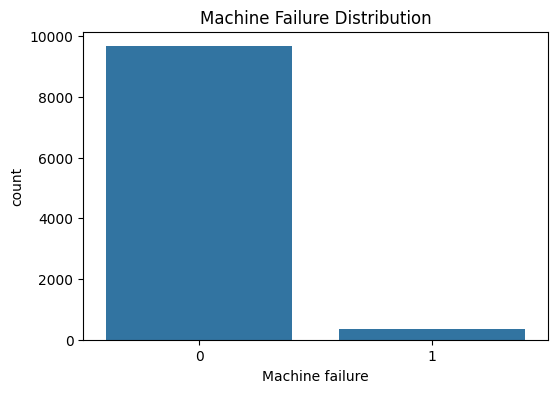

In [3]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Machine failure"
)

plt.title("Machine Failure Distribution")

plt.show()

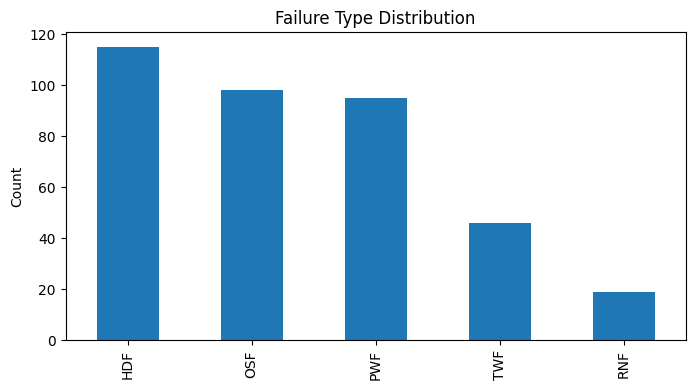

In [4]:
failure_columns= [
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]
failure_counts= df[failure_columns].sum()
plt.figure(figsize=(8,4))
failure_counts.sort_values(
    ascending=False
).plot(kind="bar")

plt.title("Failure Type Distribution")

plt.ylabel("Count")

plt.show()

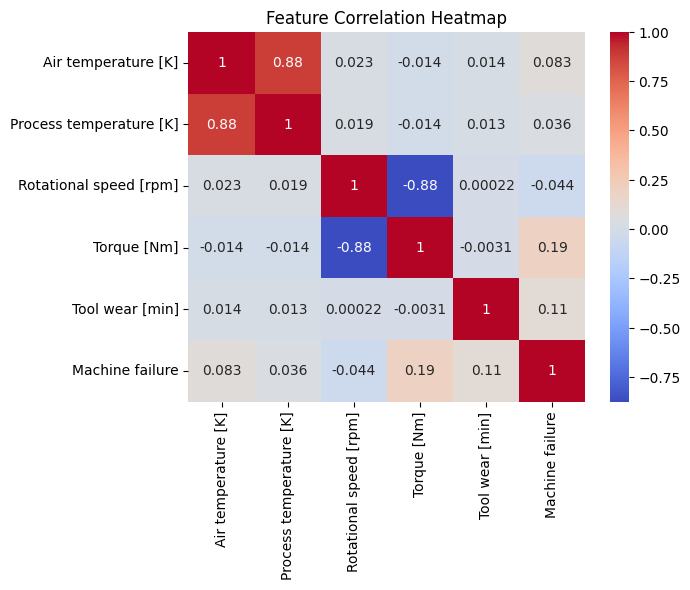

In [6]:
correlation_columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Machine failure"
]

plt.Figure(figsize=(8,6))

sns.heatmap(
    df[correlation_columns].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

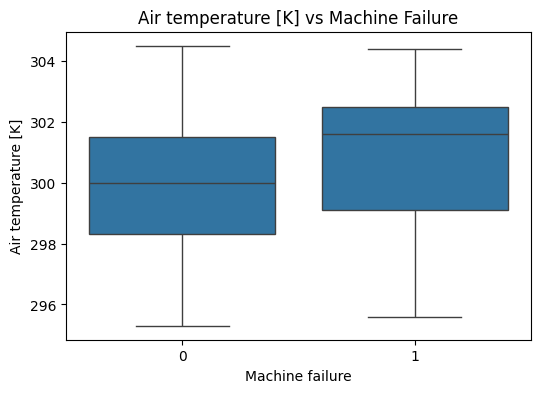

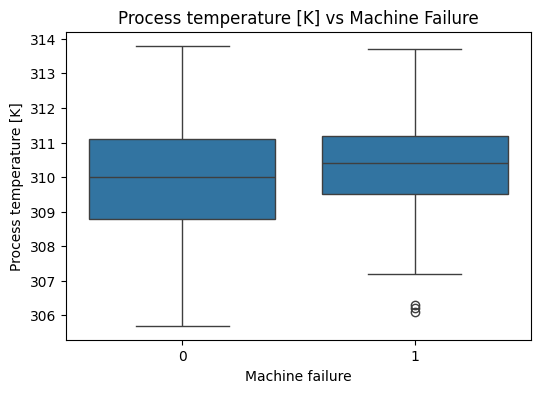

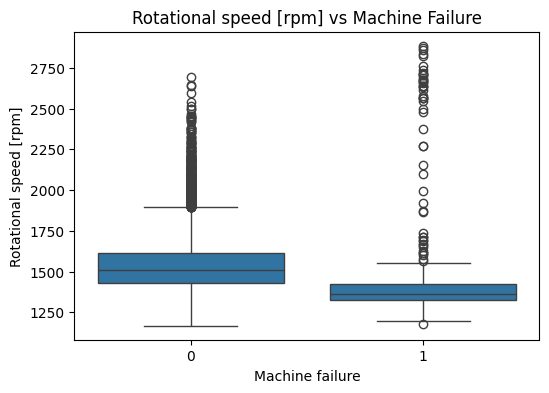

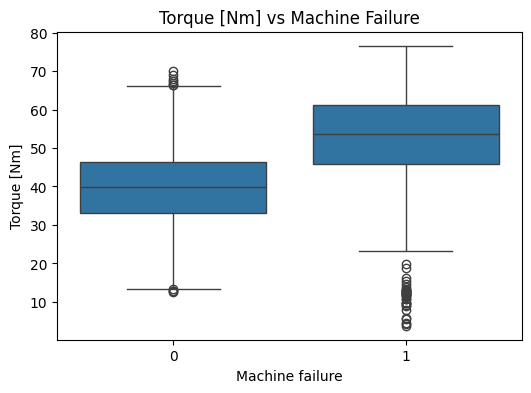

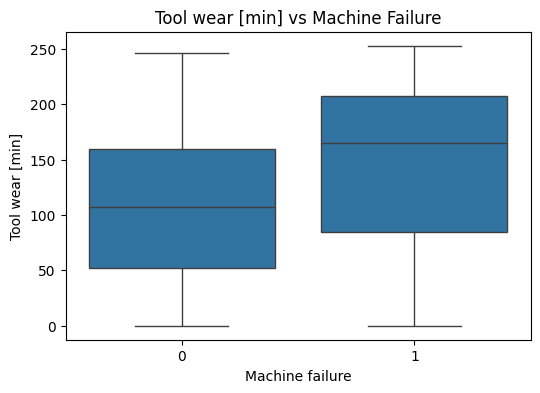

In [8]:
numeric_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

for feature in numeric_features:
    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=df,
        x="Machine failure",
        y=feature
    )

    plt.title( f"{feature} vs Machine Failure")
    plt.show()

Feature Engineering Candidates

1. Temperature Difference
   = Process Temperature - Air Temperature

2. Power Proxy
   = Rotational Speed × Torque

3. Mechanical Stress Index
   = Torque / Rotational Speed

4. Tool Wear Severity
   = Tool Wear normalized

5. Thermal Stress Index
   = Temperature Difference × Torque

# Distribution Plots

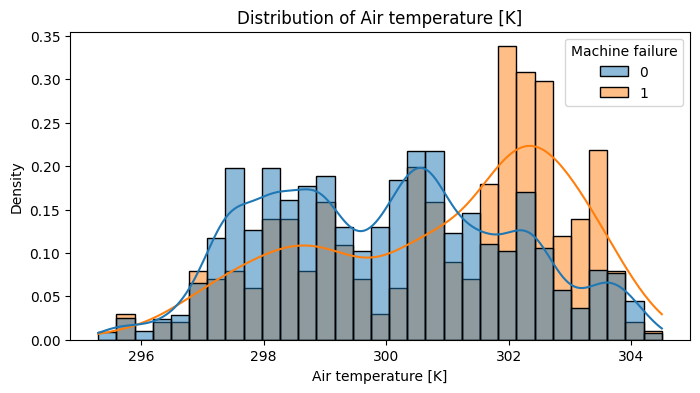

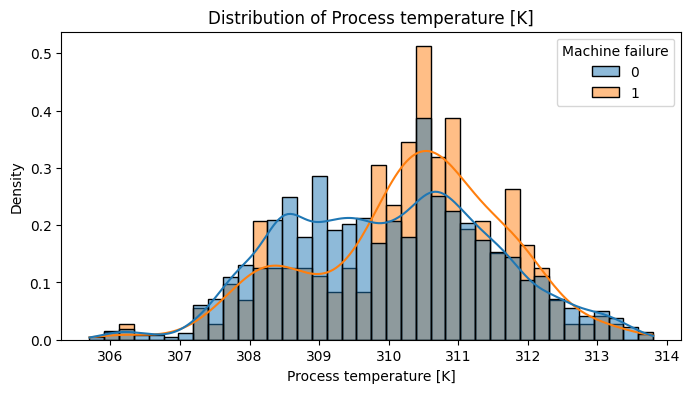

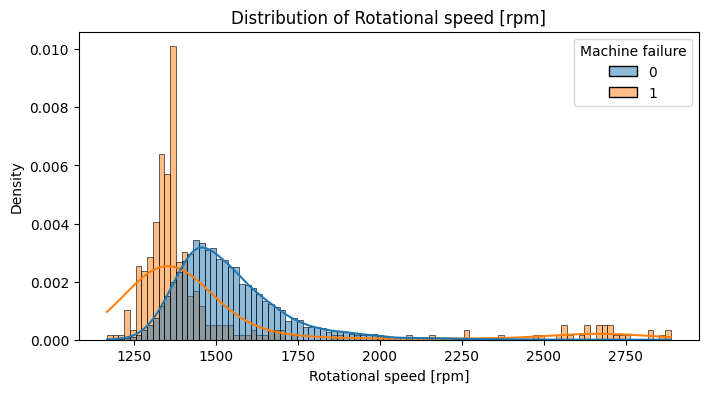

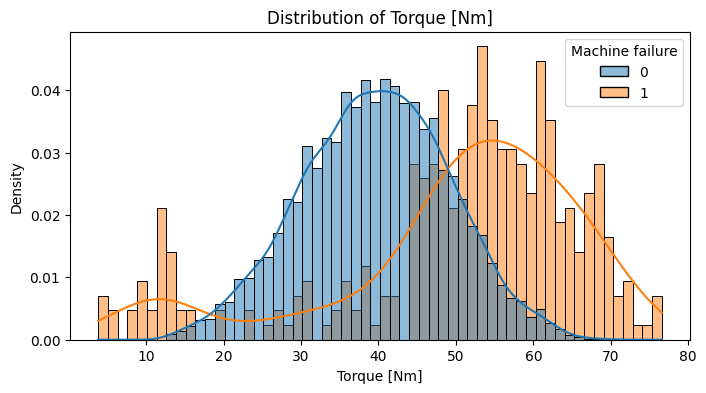

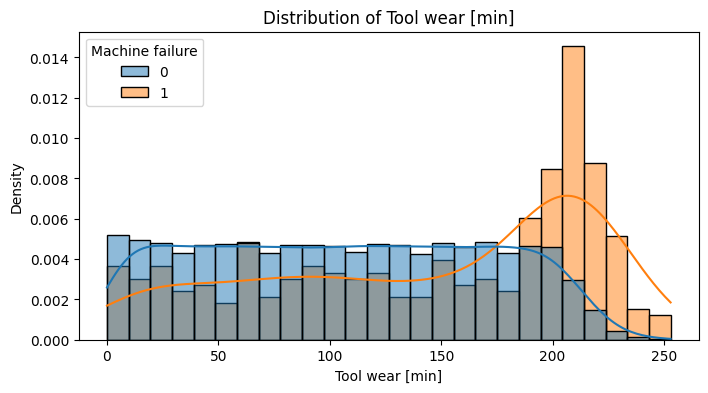

In [9]:
numeric_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

for feature in numeric_features:

    plt.figure(figsize=(8,4))

    sns.histplot(
        data=df,
        x=feature,
        hue="Machine failure",
        kde=True,
        stat="density",
        common_norm=False
    )

    plt.title(f"Distribution of {feature}")

    plt.show()